## 1. Importing Libraries and setting up CUDA



In [1]:
import os
import shutil
from IPython.display import Image, clear_output

import numpy as np
import torch
import json

import matplotlib.pyplot as plt

In [2]:
%config Completer.use_jedi = False


In [3]:
device = 'cuda' if torch.cuda.is_available() else "cpu"
device

'cuda'

## 2. Preparing Data for Training


### 2.1 Verifications of Dataset Structure


In [4]:
for dirpath, dirnames, filenames in os.walk("/kaggle/input/"):
    for dirname in dirnames:
        full_path = os.path.join(dirpath, dirname)
        print(full_path)

/kaggle/input/datasets
/kaggle/input/datasets/awsaf49
/kaggle/input/datasets/awsaf49/coco-2017-dataset
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/test2017
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017


KeyboardInterrupt: 

In [5]:
# Extract the path for both the images and the annotations for it
base_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017"
images_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017"
annotations_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations"
test_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/test2017"

In [6]:
print(f"Annotations: {os.listdir(annotations_path)}")
print(f"No. of training images: {len(os.listdir(images_path))}")
print(f"No. of test path: {len(os.listdir(test_path))}")

Annotations: ['person_keypoints_train2017.json', 'instances_val2017.json', 'instances_train2017.json', 'person_keypoints_val2017.json', 'captions_train2017.json', 'captions_val2017.json']
No. of training images: 118287
No. of test path: 40670


In [7]:
for dirpath, dirnames, filenames in os.walk(annotations_path):
    for filename in filenames: 
        full_path = os.path.join(dirpath, filename)
        print(full_path)

/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/person_keypoints_train2017.json
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_val2017.json
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_train2017.json
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/person_keypoints_val2017.json
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/captions_train2017.json
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/captions_val2017.json


### 2.2 Modifying the dataset as per the YOLO requirements
Here, we parse the COCO data/ build the helper functions as per required

1. **Letterboxing**
   This reshapes the images to the square shape, while padding for the side where needed. This improves GPU optimization, Batch processing and so on.

2. **Aggregation**
    This aggregrates all bounding box annotations by image ID

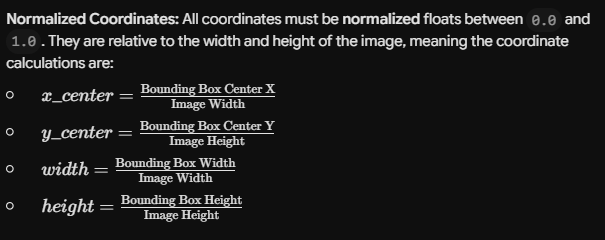

In [8]:
# LetterBoxing + converts bounding box to cooridinates on a unit square

def scale_box(box, width, height):
    scale = 1.0 / max(width, height)
    x, y , w, h = [v * scale for v in box]
    x += (height - width) * scale / 2 if height > width else 0
    y += (width - height) * scale / 2 if width > height else 0
    return [x,y,w,h]

### 2.3 Sneak-peak at the json file for annotations and Aggregation


In [9]:
train_instances_json = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_train2017.json"

In [10]:
with open(train_instances_json, "r") as file:
    data = json.load(file)

type(data)

dict

In [11]:
data.keys()

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])

In [12]:
data['images'][0]

{'license': 3,
 'file_name': '000000391895.jpg',
 'coco_url': 'http://images.cocodataset.org/train2017/000000391895.jpg',
 'height': 360,
 'width': 640,
 'date_captured': '2013-11-14 11:18:45',
 'flickr_url': 'http://farm9.staticflickr.com/8186/8119368305_4e622c8349_z.jpg',
 'id': 391895}

In [13]:
data['annotations'][0]

{'segmentation': [[239.97,
   260.24,
   222.04,
   270.49,
   199.84,
   253.41,
   213.5,
   227.79,
   259.62,
   200.46,
   274.13,
   202.17,
   277.55,
   210.71,
   249.37,
   253.41,
   237.41,
   264.51,
   242.54,
   261.95,
   228.87,
   271.34]],
 'area': 2765.1486500000005,
 'iscrowd': 0,
 'image_id': 558840,
 'bbox': [199.84, 200.46, 77.71, 70.88],
 'category_id': 58,
 'id': 156}

In [14]:
len(data['annotations'])

860001

In [15]:
# Aggregating Metadata
images = {image['id']: image for image in data['images']}

metadata = {}
for annotation in data['annotations']:
    id = annotation['image_id']
    if id not in metadata:
        metadata[id] = {
            "boxes" : [], 
            "labels" : []
        }

    image = images[id]
    box = scale_box(annotation['bbox'], image['width'], image['height'])
    metadata[id]['boxes'].append(box)
    metadata[id]['labels'].append(annotation['category_id'])
    metadata[id]["path"] = images_path + "/" + image['file_name']

metadata = list(metadata.values())    

In [16]:
metadata[0]

{'boxes': [[0.31225, 0.4796250000000001, 0.121421875, 0.11075],
  [0.508234375, 0.3295, 0.05260937500000001, 0.165609375],
  [0.263828125, 0.3085625, 0.049093750000000005, 0.13864062500000002],
  [0.003, 0.30376562500000004, 0.05460937500000001, 0.273984375],
  [0.54153125, 0.168078125, 0.456265625, 0.537046875],
  [0.3735625, 0.23315625, 0.0310625, 0.11989062500000001],
  [0.640515625, 0.503, 0.11225000000000002, 0.07831250000000001],
  [0.0015, 0.168, 0.1454375, 0.25039062500000003],
  [0.431859375, 0.187984375, 0.049609375000000004, 0.096203125],
  [0.005203125, 0.57884375, 0.56146875, 0.244359375],
  [0.6461562500000001,
   0.48187500000000005,
   0.11373437500000001,
   0.08809375000000001]],
 'labels': [58, 44, 44, 47, 1, 44, 50, 1, 44, 67, 50],
 'path': '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000558840.jpg'}

In [17]:
!pip install pycocotools

In [18]:
len(metadata)

117266

### 2.4 Listing classes in COCO Dataset

In [19]:
from pycocotools.coco import COCO

coco = COCO(train_instances_json)

loading annotations into memory...
Done (t=12.34s)
creating index...
index created!


In [20]:
categories = coco.loadCats(coco.getCatIds())
class_names = [category['name'] for category in categories]
print("Classes in COCO dataset", class_names)

Classes in COCO dataset ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


In [21]:
categories_by_name = {category['id']: category['name'] for category in categories}
categories_by_name

{1: 'person',
 2: 'bicycle',
 3: 'car',
 4: 'motorcycle',
 5: 'airplane',
 6: 'bus',
 7: 'train',
 8: 'truck',
 9: 'boat',
 10: 'traffic light',
 11: 'fire hydrant',
 13: 'stop sign',
 14: 'parking meter',
 15: 'bench',
 16: 'bird',
 17: 'cat',
 18: 'dog',
 19: 'horse',
 20: 'sheep',
 21: 'cow',
 22: 'elephant',
 23: 'bear',
 24: 'zebra',
 25: 'giraffe',
 27: 'backpack',
 28: 'umbrella',
 31: 'handbag',
 32: 'tie',
 33: 'suitcase',
 34: 'frisbee',
 35: 'skis',
 36: 'snowboard',
 37: 'sports ball',
 38: 'kite',
 39: 'baseball bat',
 40: 'baseball glove',
 41: 'skateboard',
 42: 'surfboard',
 43: 'tennis racket',
 44: 'bottle',
 46: 'wine glass',
 47: 'cup',
 48: 'fork',
 49: 'knife',
 50: 'spoon',
 51: 'bowl',
 52: 'banana',
 53: 'apple',
 54: 'sandwich',
 55: 'orange',
 56: 'broccoli',
 57: 'carrot',
 58: 'hot dog',
 59: 'pizza',
 60: 'donut',
 61: 'cake',
 62: 'chair',
 63: 'couch',
 64: 'potted plant',
 65: 'bed',
 67: 'dining table',
 70: 'toilet',
 72: 'tv',
 73: 'laptop',
 74: 'mo

In [22]:
metadata[435]

{'boxes': [[0.12471874999999999, 0.275, 0.57640625, 0.333703125],
  [0.0, 0.152078125, 0.7938125, 0.687640625],
  [0.0, 0.125140625, 1.0, 0.7498593750000001]],
 'labels': [17, 15, 2],
 'path': '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000171809.jpg'}

In [23]:
# Example for labels

labels = [categories_by_name[id] for id in metadata[435]['labels']]
labels

['cat', 'bench', 'bicycle']

In [24]:
list(images.keys())[435]

557556

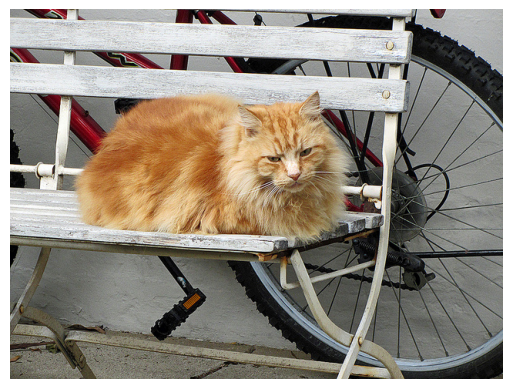

In [25]:
from PIL import Image

img = Image.open("/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000171809.jpg")
plt.imshow(img)
plt.axis('off')
plt.show()

In [26]:
images[171809]['coco_url']

'http://images.cocodataset.org/train2017/000000171809.jpg'

In [27]:
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from matplotlib.patches import Rectangle

color_map = {0:'gray'}

def label_to_color(label):
    # Uses the golden ratio to generate new hues of a bright color with
    # the HSV colorspace
    if label not in color_map:
        h, s, v = (len(color_map) * 0.618) % 1, 0.5, 0.9
        color_map[label] = hsv_to_rgb((h, s, v))
    return color_map[label]

def draw_box(ax, box, text, color):
    x,y,w,h = box
    ax.add_patch(Rectangle((x,y), w, h, lw = 2, ec = color, fc='none'))
    textbox = dict(fc = color, pad = 1, ec = 'none')
    ax.text(x,y,text, c ='white', size = 10, va = 'bottom', bbox = textbox)

def draw_image(ax, image):
    # Draws the image on a unit cube with (0, 0) at the top left
    ax.set(xlim=(0, 1), ylim=(1, 0), xticks=[], yticks=[], aspect="equal")
    image = plt.imread(image)
    height, width = image.shape[:2]
    # Pads the image so it fits inside the unit cube
    hpad = (1 - height / width) / 2 if width > height else 0
    wpad = (1 - width / height) / 2 if height > width else 0
    extent = [wpad, 1 - wpad, 1 - hpad, hpad]
    ax.imshow(image, extent=extent)

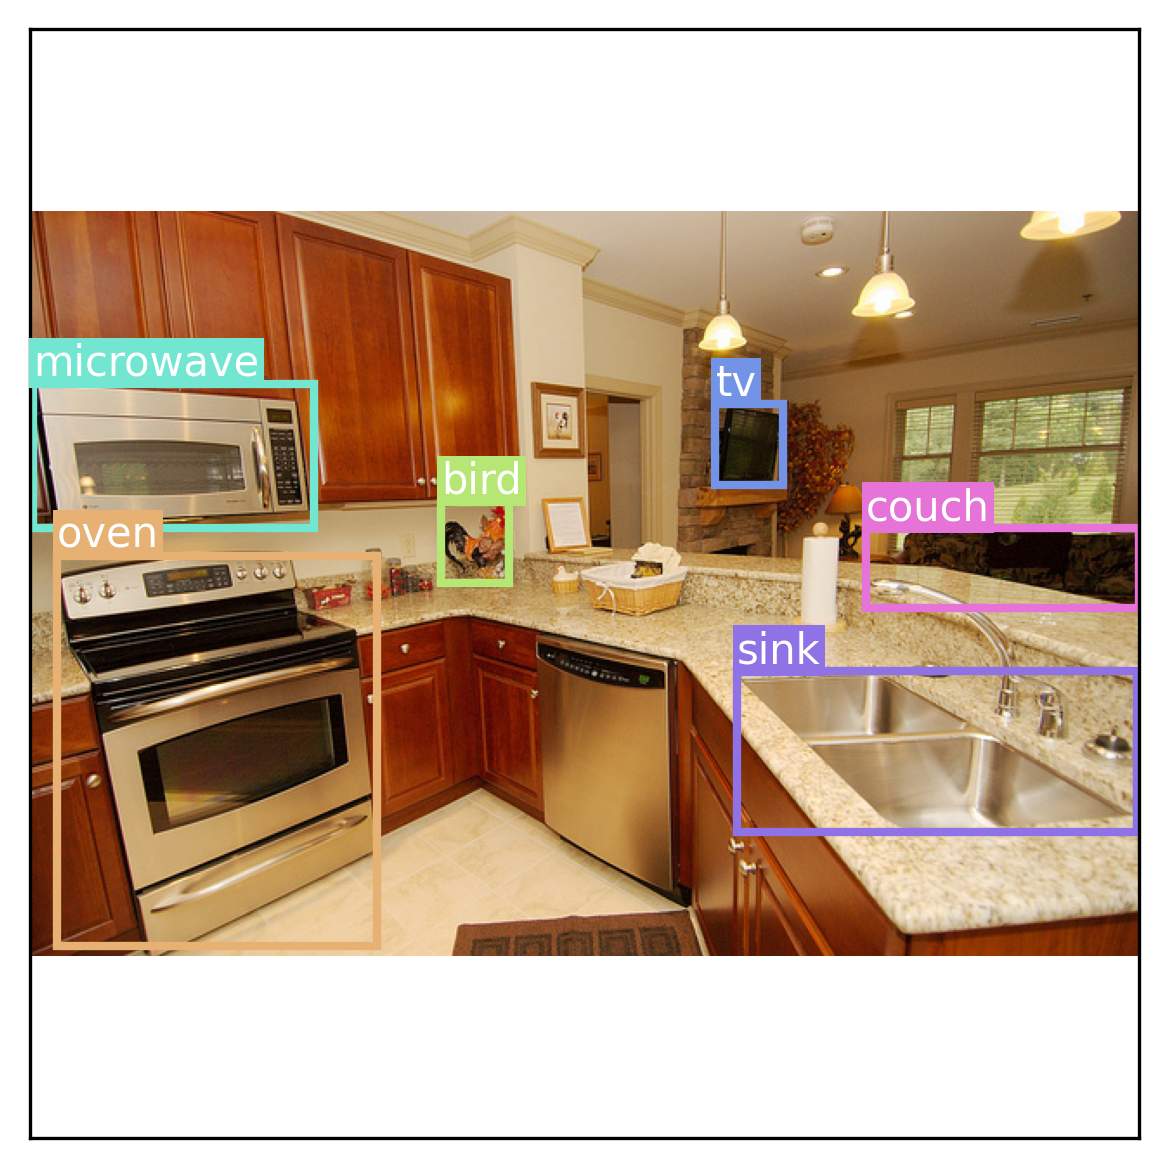

In [28]:
sample = metadata[300]
ig, ax = plt.subplots(dpi = 300)
draw_image(ax, sample['path'])
for box, label_id in zip(sample['boxes'], sample['labels']):
    class_name = categories_by_name[label_id]
    draw_box(ax, box, class_name, color = label_to_color(label_id))
plt.show()

## 3. Creating a YOLO (You Only Look Once) Model

Here, we create a YOLO model, which is a single stage detector

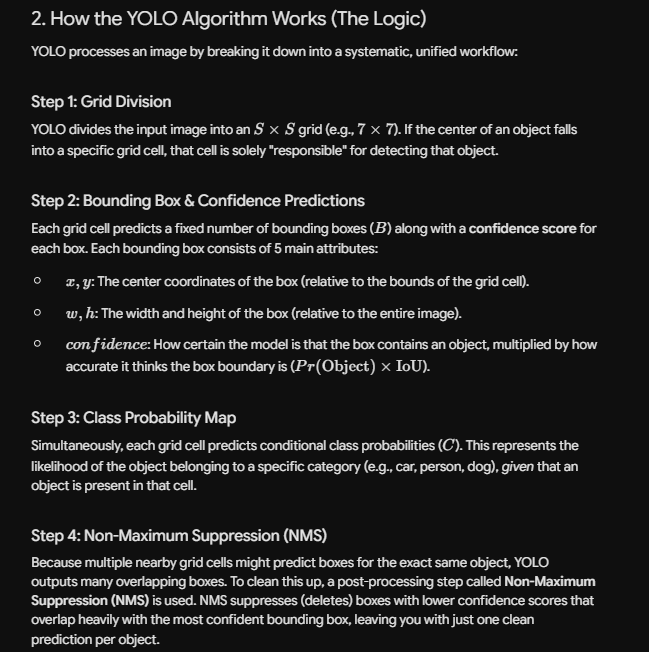

### 3.1 Loading the pretrained RESNET (or architecture of your choice) as the backbone

In [29]:
import torchvision
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.IMAGENET1K_V2

In [30]:
import torch.nn as nn
from torchsummary import summary

class YOLOR1(nn.Module):
    def __init__(self, grids = 6, num_classes  = 91):
        super(YOLOR1, self).__init__()
        self.grids = grids
        self.num_classes = num_classes

        resnet = resnet50(weights = weights)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        self.convolution = nn.Conv2d(2048, 512, kernel_size = 3, stride = 2, padding = 0)
        self.flatten = nn.Flatten()
        self.dense1 = nn.Linear(6  * 6 * 512, 2048)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.dense2 = nn.Linear(2048, grids * grids * (num_classes + 5))

    def forward(self, x):
        x = self.backbone(x) # Shape: (B, 2048, 14, 14)
        x = self.convolution(x)  # Shape: (B, 512, 6, 6)
        x = self.flatten(x) # Shape: (B, 18432)
        x = self.dense1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.dense2(x)   # Shape: (B, 3456)

        # Reshaping the output to the grid_size
        x = x.view(-1, self.grids, self.grids, self.num_classes + 5)    # Shape: (B, 6, 6, 96)
        box_preds = x[..., :5]
        class_preds = x[..., 5:]

        class_preds = torch.softmax(class_preds, dim = -1)

        return {
            "box": box_preds, 
            "class": class_preds
        }
        
model = YOLOR1().to(device)
summary(model, (3, 448, 448))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 213MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           9,408
       BatchNorm2d-2         [-1, 64, 224, 224]             128
              ReLU-3         [-1, 64, 224, 224]               0
         MaxPool2d-4         [-1, 64, 112, 112]               0
            Conv2d-5         [-1, 64, 112, 112]           4,096
       BatchNorm2d-6         [-1, 64, 112, 112]             128
              ReLU-7         [-1, 64, 112, 112]               0
            Conv2d-8         [-1, 64, 112, 112]          36,864
       BatchNorm2d-9         [-1, 64, 112, 112]             128
             ReLU-10         [-1, 64, 112, 112]               0
           Conv2d-11        [-1, 256, 112, 112]          16,384
      BatchNorm2d-12        [-1, 256, 112, 112]             512
           Conv2d-13        [-1, 256, 112, 112]          16,384
      BatchNorm2d-14        [-1, 256, 1

# 4. Preparing the COCO data as per the requirements of the YOLO model

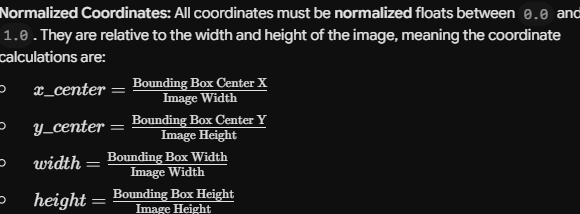

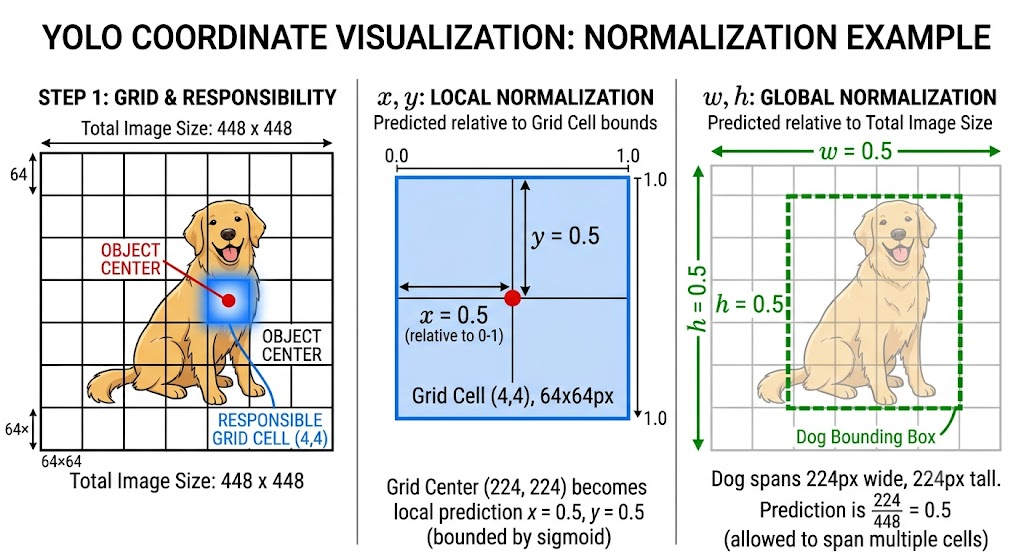
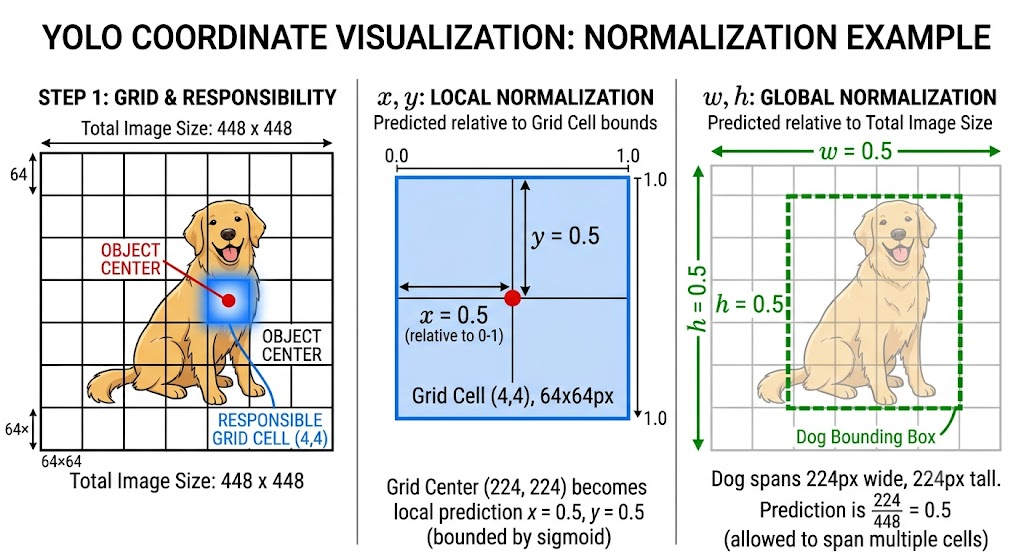

### 4.1 Conversion of Image Space to the Grid Space
Takes x, y ,w , h with respect to the entire image and returns the related grid cell and relative x, y to that grid cell as well as width, height relative to the entire image

In [1]:
# Helper function to convert to grid and to box from the grid

def to_grid(box, grid_size):
    x, y , width, height = box
    x_center, y_center = (x + width/2) * grid_size, (y + height/2) * grid_size
    ix, iy = int(x_center), int(y_center)
    offset_x, offset_y = x_center - ix, y_center - iy 
    return (ix, iy), (offset_x, offset_y, width, height)
    

### 4.2 Conversion of Grid Space to the Image Space
Reverse of previous step

In [2]:
def from_grid(loc, box, grid_size):
    (ix, iy), (offset_x, offset_y, width, height) = loc, box
    x = (ix + offset_x)/ grid_size - width / 2
    y = (iy + offset_y)/ grid_size - height/ 2
    return (x, y , width, height)